<a href="https://colab.research.google.com/github/JamesJaruphat/University-Projects/blob/main/PythiumSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pythium Semantic Segmentation U-Net Model**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install segmentation-models-pytorch


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 880.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import segmentation_models_pytorch as smp

In [ ]:
# ตั้งค่า device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# ตั้งค่าการแปลงภาพและ mask
transform_image = transforms.Compose([
    transforms.ToTensor()
])

transform_mask = transforms.Compose([
    transforms.PILToTensor(),  # คงค่า mask เป็น int
    transforms.Lambda(lambda x: x.squeeze(0).long())  # ลดขนาด channel และทำเป็น long tensor
])

ค้นหารายชื่อไฟล์ภาพที่ไม่มี _mask

In [ ]:
class FungiSegmentationDataset(Dataset):
    def __init__(self, images_dir, transform_image=None, transform_mask=None):
        self.images_dir = images_dir
        self.transform_image = transform_image
        self.transform_mask = transform_mask

        self.images = [f for f in os.listdir(images_dir) if (f.endswith(".jpg") or f.endswith(".png")) and "_mask" not in f]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.images_dir, img_name.replace(".jpg", "_mask.png"))

        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask not found for image {img_name} at path {mask_path}")

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform_image:
            image = self.transform_image(image)
        if self.transform_mask:
            mask = self.transform_mask(mask).squeeze(0)  # ต้องการให้ mask เป็น single-channel

        return image, mask


Load Images/Masks and Random Split

In [ ]:
import os
from torch.utils.data import ConcatDataset, random_split

# กำหนด path ของชุดข้อมูลเดิม
train_image_dir = '/content/drive/MyDrive/Thesis/dataset01/train'
valid_image_dir = '/content/drive/MyDrive/Thesis/dataset01/valid'
test_image_dir = '/content/drive/MyDrive/Thesis/dataset01/test'

# โหลด dataset จากทั้งสามโฟลเดอร์
train_dataset = FungiSegmentationDataset(train_image_dir, transform_image, transform_mask)
valid_dataset = FungiSegmentationDataset(valid_image_dir, transform_image, transform_mask)
test_dataset = FungiSegmentationDataset(test_image_dir, transform_image, transform_mask)

# รวม dataset ทั้งหมดเข้าด้วยกัน
full_dataset = ConcatDataset([train_dataset, valid_dataset, test_dataset])

# แยก pythium และ non-pythium ออกจากกัน
pythium_data = []
non_pythium_data = []

for img, mask in full_dataset:
    if (mask == 2).any():  # มี Pythium
        pythium_data.append((img, mask))
    else:  # เป็น Non-Pythium
        non_pythium_data.append((img, mask))

# ตรวจสอบจำนวนข้อมูล
print(f"Total Pythium: {len(pythium_data)}, Total Non-Pythium: {len(non_pythium_data)}")

# ตรวจสอบว่าข้อมูลเป็น 2:1 หรือไม่
assert len(pythium_data) == 240 and len(non_pythium_data) == 120, "จำนวนข้อมูลไม่ถูกต้อง"

# ใช้ random_split แบ่งข้อมูลใหม่
pythium_train, pythium_valid, pythium_test = random_split(
    pythium_data, [210, 20, 10], generator=torch.Generator().manual_seed(42)
)
non_pythium_train, non_pythium_valid, non_pythium_test = random_split(
    non_pythium_data, [105, 10, 5], generator=torch.Generator().manual_seed(42)
)

# รวม pythium และ non-pythium กลับเป็น dataset สุดท้าย
train_dataset = pythium_train + non_pythium_train
valid_dataset = pythium_valid + non_pythium_valid
test_dataset = pythium_test + non_pythium_test

# สร้าง DataLoader ใหม่
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"New dataset sizes - Train: {len(train_dataset)}, Valid: {len(valid_dataset)}, Test: {len(test_dataset)}")


Total Pythium: 240, Total Non-Pythium: 120
New dataset sizes - Train: 315, Valid: 30, Test: 15


Load Model U-Net

In [ ]:
model = smp.Unet(
    encoder_name="resnet50",        # ใช้ ResNet-50 เป็น backbone
    encoder_weights="imagenet",    # ใช้น้ำหนัก pretrained
    in_channels=3,                 # input channels (เช่น RGB)
    classes=3                      # output classes: background, non-pythium, pythium
)

Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /root/.cache/torch/hub/checkpoints/resnet50-19c8e357.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 209MB/s]


In [ ]:
# ใช้ CrossEntropyLoss และ Adam Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


Model Training

In [ ]:
# Training Loop
num_epochs = 40

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)  # output จาก UNet
        loss = criterion(outputs, masks)

        # Backward and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {running_loss / len(train_loader):.4f}')

    # Validation phase
    model.eval()
    valid_loss = 0.0
    with torch.no_grad():
        for images, masks in valid_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            valid_loss += loss.item()

        print(f'Validation Loss: {valid_loss / len(valid_loader):.4f}')

Epoch [1/40], Loss: 0.9936
Validation Loss: 0.8763
Epoch [2/40], Loss: 0.6855
Validation Loss: 0.7021
Epoch [3/40], Loss: 0.5480
Validation Loss: 0.5005
Epoch [4/40], Loss: 0.4536
Validation Loss: 0.4267
Epoch [5/40], Loss: 0.3804
Validation Loss: 0.3661
Epoch [6/40], Loss: 0.3167
Validation Loss: 0.3055
Epoch [7/40], Loss: 0.2710
Validation Loss: 0.2722
Epoch [8/40], Loss: 0.2404
Validation Loss: 0.2568
Epoch [9/40], Loss: 0.2215
Validation Loss: 0.2352
Epoch [10/40], Loss: 0.2051
Validation Loss: 0.2198
Epoch [11/40], Loss: 0.1788
Validation Loss: 0.1933
Epoch [12/40], Loss: 0.1751
Validation Loss: 0.1895
Epoch [13/40], Loss: 0.1581
Validation Loss: 0.1876
Epoch [14/40], Loss: 0.1376
Validation Loss: 0.1528
Epoch [15/40], Loss: 0.1279
Validation Loss: 0.1457
Epoch [16/40], Loss: 0.1159
Validation Loss: 0.1415
Epoch [17/40], Loss: 0.1063
Validation Loss: 0.1313
Epoch [18/40], Loss: 0.0977
Validation Loss: 0.1359
Epoch [19/40], Loss: 0.0932
Validation Loss: 0.1198
Epoch [20/40], Loss: 

Evaluation

Segmentation Performance

In [ ]:
import numpy as np

# ฟังก์ชันสำหรับคำนวณ IoU
def compute_iou(pred, target, num_classes):
    iou_list = []
    pred = pred.view(-1)  # flatten
    target = target.view(-1)  # flatten

    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (target == cls)
        intersection = (pred_inds[target_inds]).long().sum().item()  # And
        union = pred_inds.long().sum().item() + target_inds.long().sum().item() - intersection  # Or

        if union == 0:
            iou_list.append(float('nan'))  # หลีกเลี่ยงการหารด้วย 0
        else:
            iou_list.append(intersection / union)

    return iou_list

# ฟังก์ชันสำหรับคำนวณ pixel accuracy
def compute_pixel_accuracy(pred, target):
    correct = (pred == target).sum().item()
    total = target.numel()
    return correct / total

# Evaluation
def evaluate_model(model, dataloader, num_classes=3):
    model.eval()
    total_iou = np.zeros(num_classes)
    total_pixel_accuracy = 0.0
    count = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)  # ใช้ class ที่มีค่าสูงสุดเป็นผลทำนาย

            # คำนวณ IoU และ Pixel Accuracy
            iou = compute_iou(preds, masks, num_classes)
            pixel_accuracy = compute_pixel_accuracy(preds, masks)

            # เก็บค่าผลลัพธ์สะสม
            total_iou += np.array(iou)
            total_pixel_accuracy += pixel_accuracy
            count += 1

    # คำนวณค่าเฉลี่ย
    mean_iou = np.nanmean(total_iou / count)  # mIoU โดยหาค่าเฉลี่ยแบบไม่นับ nan
    mean_pixel_accuracy = total_pixel_accuracy / count

    print(f"Mean IoU: {mean_iou:.4f}")
    print(f"Pixel Accuracy: {mean_pixel_accuracy:.4f}")

# เรียกใช้ evaluation function บน test set
evaluate_model(model, test_loader, num_classes=3)


Mean IoU: 0.8768
Pixel Accuracy: 0.9782


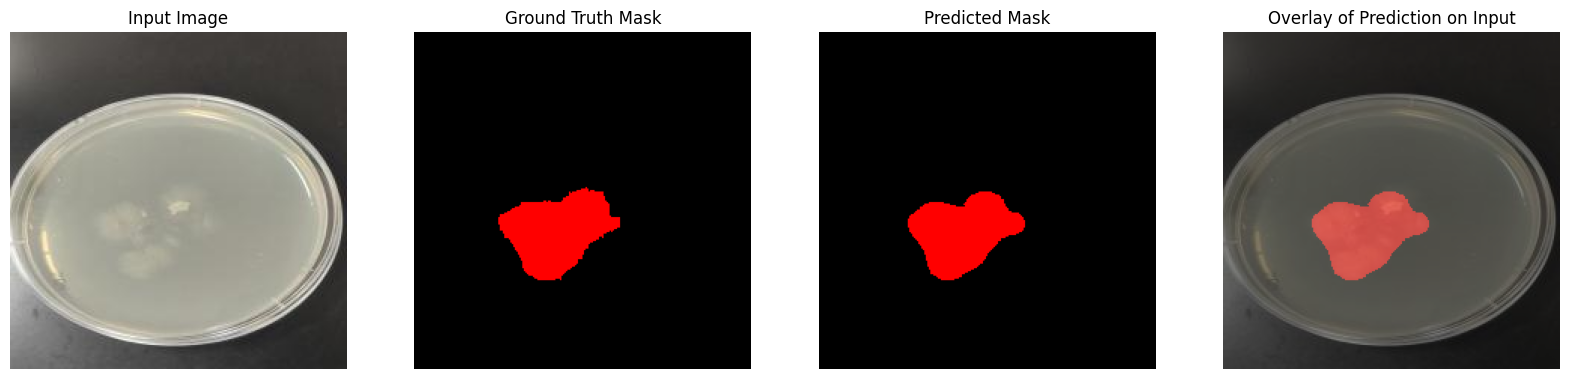

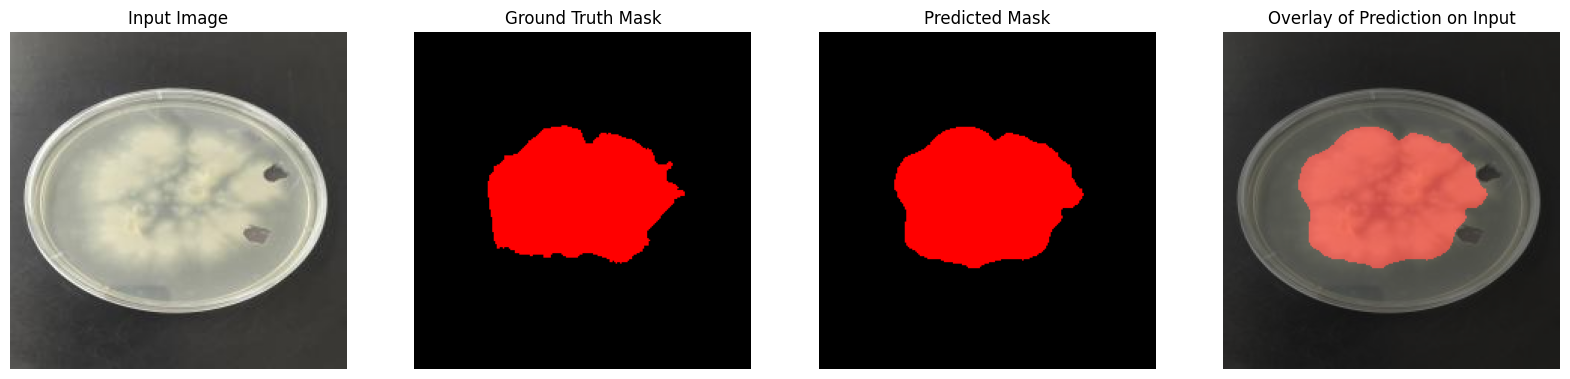

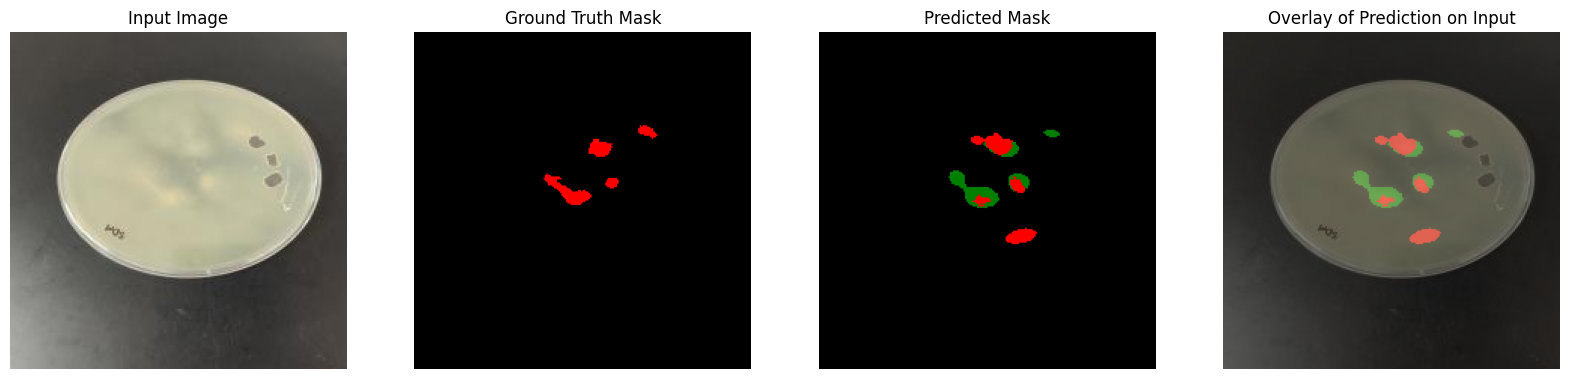

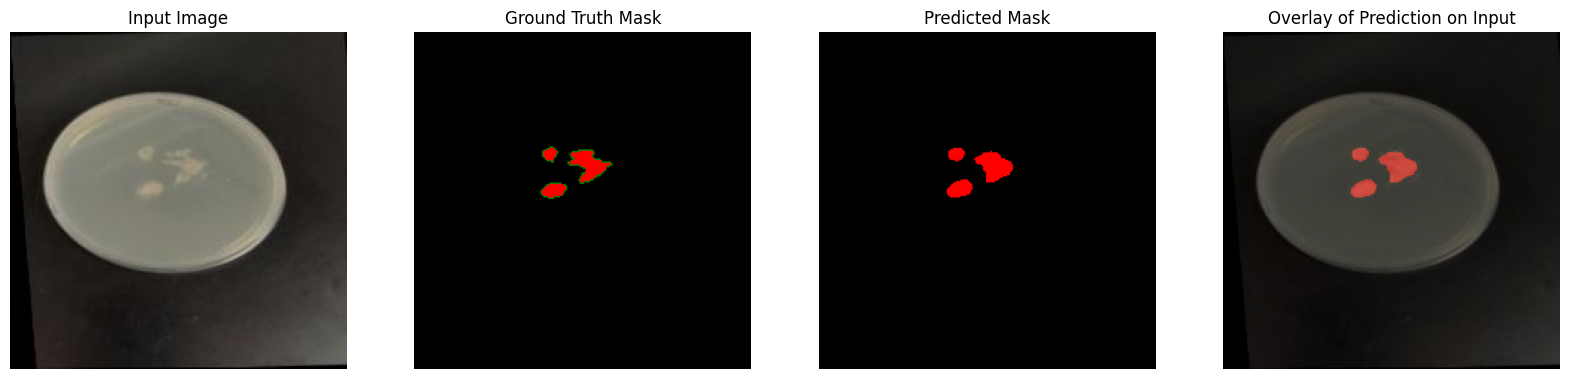

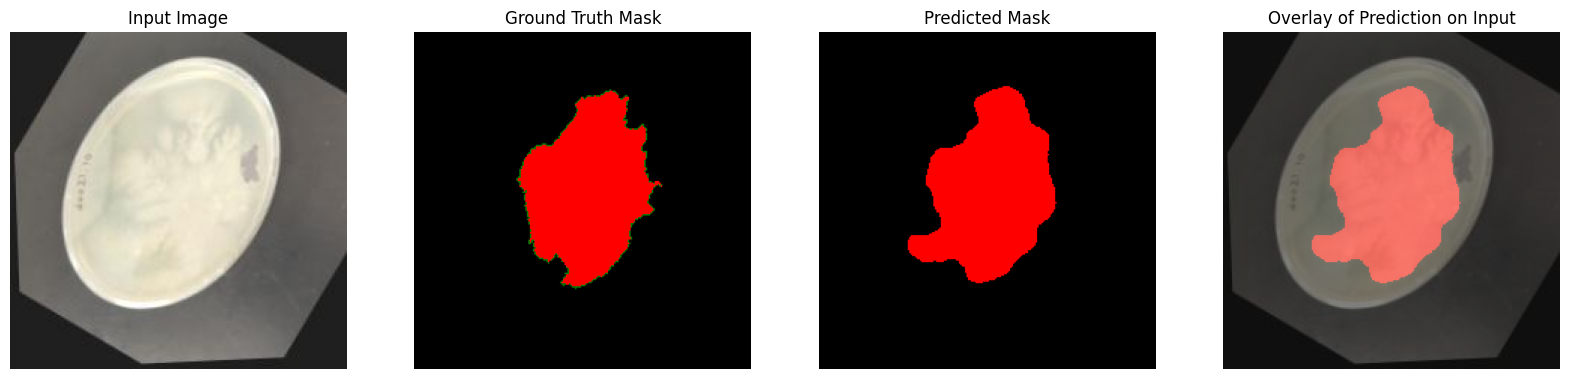

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def display_predictions(model, dataloader, num_images=5):
    model.eval()

    # Define the colors for each class: background (black), non-pythium (green), pythium (red)
    cmap = mcolors.ListedColormap(['black', 'green', 'red'])

    images_shown = 0
    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)  # ใช้คลาสที่มีค่าสูงสุดเป็นผลทำนาย

            for i in range(images.size(0)):
                if images_shown >= num_images:
                    return

                # แปลง tensor เป็น numpy เพื่อให้ matplotlib แสดงผลได้
                image_np = images[i].cpu().numpy().transpose(1, 2, 0)
                mask_np = masks[i].cpu().numpy()
                pred_np = preds[i].cpu().numpy()

                # แสดงภาพ input, mask จริง, และ mask ที่ทำนายซ้อนบนภาพ input
                fig, axs = plt.subplots(1, 4, figsize=(20, 5))
                axs[0].imshow(image_np)
                axs[0].set_title("Input Image")
                axs[0].axis("off")

                axs[1].imshow(mask_np, cmap=cmap, vmin=0, vmax=2)
                axs[1].set_title("Ground Truth Mask")
                axs[1].axis("off")

                axs[2].imshow(pred_np, cmap=cmap, vmin=0, vmax=2)
                axs[2].set_title("Predicted Mask")
                axs[2].axis("off")

                # แสดง predicted mask ซ้อนบน input image
                axs[3].imshow(image_np)
                axs[3].imshow(pred_np, cmap=cmap, vmin=0, vmax=2, alpha=0.5)  # alpha ทำให้ mask โปร่งใส
                axs[3].set_title("Overlay of Prediction on Input")
                axs[3].axis("off")

                plt.show()
                images_shown += 1

# เรียกฟังก์ชันเพื่อแสดงภาพที่โมเดลทำนาย
display_predictions(model, test_loader, num_images=5)


Classification Performance

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

def evaluate_segmentation_as_table(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, masks in data_loader:
            images = images.to(device)
            masks = masks.to(device)  # Ground truth mask

            # ทำนายผล
            outputs = model(images)  # Shape: [batch_size, num_classes, H, W]
            preds = torch.argmax(outputs, dim=1)  # เลือก class ที่มีความน่าจะเป็นสูงสุด
            preds = preds.cpu().numpy()  # นำผลทำนายออกมาเป็น numpy array
            masks = masks.cpu().numpy()  # Ground truth masks

            # Flatten outputs และ ground truth เพื่อให้ใช้กับ sklearn metrics ได้
            all_preds.extend(preds.flatten())
            all_labels.extend(masks.flatten())

    # คำนวณ metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, labels=[1, 2], average=None)  # สำหรับ class non-pythium (1) และ pythium (2)
    recall = recall_score(all_labels, all_preds, labels=[1, 2], average=None)
    f1 = f1_score(all_labels, all_preds, labels=[1, 2], average=None)

    # คำนวณ confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])  # รวม background (0)
    class_accuracies = []
    for i in [1, 2]:  # เฉพาะ non-pythium (1) และ pythium (2)
        tp = cm[i, i]
        total = np.sum(cm[i, :])  # จำนวนทั้งหมดใน class นั้น (TP + FN)
        class_accuracies.append(tp / total if total > 0 else 0)

    # คำนวณ IoU
    iou_non_pythium = np.sum((np.array(all_preds) == 1) & (np.array(all_labels) == 1)) / \
                      np.sum((np.array(all_preds) == 1) | (np.array(all_labels) == 1))
    iou_pythium = np.sum((np.array(all_preds) == 2) & (np.array(all_labels) == 2)) / \
                  np.sum((np.array(all_preds) == 2) | (np.array(all_labels) == 2))

    # สร้าง DataFrame สำหรับแสดงผลในรูปแบบตาราง
    metrics_table = pd.DataFrame({
        "Class": ["Non-Pythium (1)", "Pythium (2)"],
        "Accuracy": class_accuracies,
        "Precision": [precision[0], precision[1]],
        "Recall": [recall[0], recall[1]],
        "F1-Score": [f1[0], f1[1]],
        "IoU": [iou_non_pythium, iou_pythium]
    })

    # แสดงผลตาราง
    print(f"Overall Accuracy: {accuracy:.4f}\n")
    print(metrics_table)

# เรียกใช้งานฟังก์ชัน
evaluate_segmentation_as_table(model, valid_loader, device)


Overall Accuracy: 0.9748

             Class  Accuracy  Precision    Recall  F1-Score       IoU
0  Non-Pythium (1)  0.921778   0.943039  0.921778  0.932288  0.873163
1      Pythium (2)  0.912310   0.882626  0.912310  0.897222  0.813602
